In [1]:
import rasterio
import numpy as np
import pandas as pd
from minisom import MiniSom
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn_extra.cluster import KMedoids
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
from tqdm import tqdm


In [ ]:

# 1. Lade die Rasterdaten (nur gewünschte Bänder)
firemetrics_dir = r"A:/_BioGeo/butzerfe/thesis/_Runs/01_Fire_Metrics/MBA_3km_3035"

# Dateipfade
files = [
    f"{firemetrics_dir}/fire_return_interval_dual.tif",
    f"{firemetrics_dir}/fire_season_length_final.tif",
    f"{firemetrics_dir}/MBA_MeanFractionBurned_3km_2000-2025.tif",
    f"{firemetrics_dir}/MBA_burned_area_sum_max_final.tif"
]


#Lade Raster und extrahiere gewünschte Bänder
with rasterio.open(files[0]) as src:
    fri_classic = src.read(2)  # 2. Band

with rasterio.open(files[1]) as src:
    season_length = src.read(1)

with rasterio.open(files[2]) as src:
    mean_fraction_burned = src.read(1)

with rasterio.open(files[3]) as src:
    max_burned_area = src.read(2)  # 2. Band (km²)



# Stacke und maskiere auf gültige Werte
stack = np.stack([fri_classic, season_length, mean_fraction_burned, max_burned_area])
mask = ~np.any(np.isnan(stack), axis=0)
# Extrahiere gültige Pixel und Koordinaten
rows, cols = np.where(mask)
data = stack[:, rows, cols].T  # shape: (n_samples, n_features)


In [ ]:

# 2. Standardisierung
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)


In [ ]:
# 3. SOM-Training
n_samples = data_scaled.shape[0]
m = int(5 * np.sqrt(n_samples))
xdim = int(np.floor(np.sqrt(m)))
ydim = int(np.ceil(m / xdim))

som = MiniSom(xdim, ydim, data_scaled.shape[1], sigma=1.0, learning_rate=0.5, neighborhood_function='gaussian', random_seed=42)
som.train(data_scaled, 3500, verbose=True)

#  prüfen, ob alle SOM-Gewichte finite Werte haben:
#  Wenn das False ergibt, ist alles ok.

import numpy as np
print(np.any(~np.isfinite(som.get_weights())))

Hier ist ein Beispiel, wie du den Silhouette-Score in Python für verschiedene Clusterzahlen auf den SOM-Codebook-Vektoren berechnest und visualisierst:

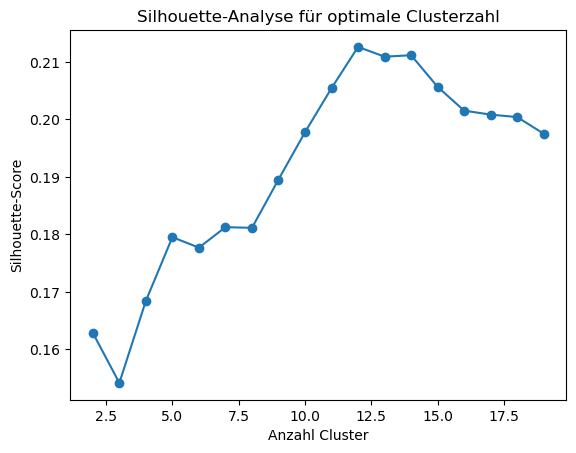

In [39]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import numpy as np
# SOM-Codebook-Vektoren (wie vorher)
codes = som.get_weights().reshape(-1, data_scaled.shape[1])

sil_scores = []
k_range = range(2, 20)  # Anzahl Cluster
for k in k_range:
    clustering = AgglomerativeClustering(n_clusters=k).fit(codes)
    labels = clustering.labels_
    score = silhouette_score(codes, labels)
    sil_scores.append(score)

plt.plot(list(k_range), sil_scores, marker='o')
plt.xlabel("Anzahl Cluster")
plt.ylabel("Silhouette-Score")
plt.title("Silhouette-Analyse für optimale Clusterzahl")
plt.show()


optimal_k = k_range[np.argmax(sil_scores)]
print(f"Optimale Clusterzahl (Silhouette): {optimal_k}")

In [61]:
# 4. Cluster auf SOM-Codebook, Clusteranzahl wähle Optimale Anzahl aus Silhouette-Analyse
clustering = AgglomerativeClustering(n_clusters=12).fit(codes)
labels = clustering.labels_


In [62]:
# Mappe jeden Datenpunkt auf einen SOM-Knoten und dann auf einen Cluster
win_map = np.array([som.winner(x) for x in data_scaled])
som_indices = win_map[:,0] * ydim + win_map[:,1]
pixel_clusters = labels[som_indices]
#anzahl werte je cluster
cluster_counts = pd.Series(pixel_clusters).value_counts().sort_index()
print(cluster_counts)

In [50]:
# 5. Cluster zurück auf Raster schreiben
cluster_raster = np.full(fri_classic.shape, np.nan)
cluster_raster[rows, cols] = pixel_clusters + 1  # Cluster-IDs ab 1

In [51]:
# Speichern
profile = rasterio.open(files[0]).profile
profile.update(dtype='float32', count=1)
with rasterio.open(f"{firemetrics_dir}/FireMetrics_SOM_Cluster_5class.tif", "w", **profile) as dst:
    dst.write(cluster_raster.astype('float32'), 1)

print("Cluster-Raster gespeichert!")

Cluster-Raster gespeichert!


In [58]:
#anzahl werte je cluster
cluster_counts = pd.Series(pixel_clusters).value_counts().sort_index()


In [60]:
cluster_counts

0    44202
1     2729
2    71489
3       35
Name: count, dtype: int64

In [66]:

unique_clusters = np.unique(cluster_raster[~np.isnan(cluster_raster)])
print(f"Anzahl der Cluster: {len(unique_clusters)}")
print(f"Cluster-IDs: {unique_clusters}")

Anzahl der Cluster: 4
Cluster-IDs: [1. 2. 3. 4.]


Agglomerative Clustering mit initial 13 Clustern und der Möglichkeit, die Clusterzahl nachträglich am Dendrogramm zu wählen:



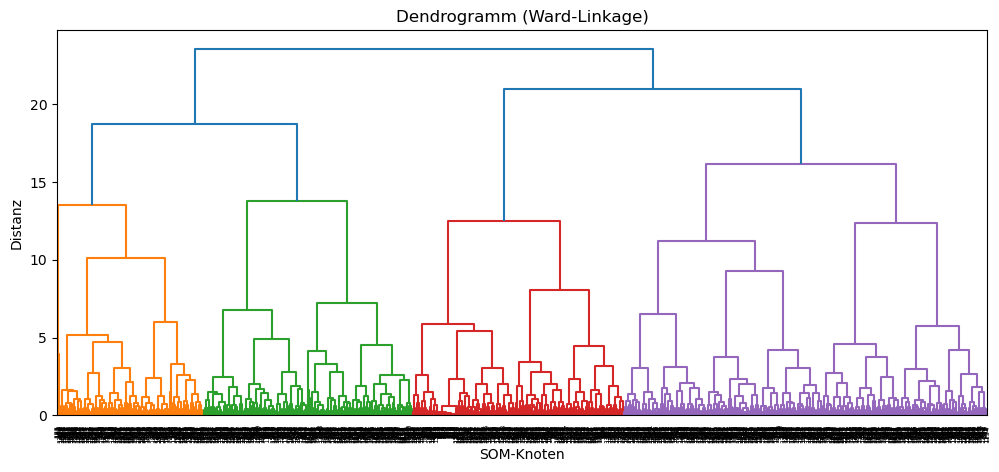

Clusterlabels für 5 Cluster berechnet.


In [70]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import AgglomerativeClustering

# Annahme: codes = SOM-Codebook-Vektoren

# 1. Agglomerative Clustering mit 13 Clustern
clustering = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels_13 = clustering.fit_predict(codes)

# 2. Dendrogramm plotten (Ward-Linkage)
Z = linkage(codes, method='ward')
plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='level', p=30)
plt.title("Dendrogramm (Ward-Linkage)")
plt.xlabel("SOM-Knoten")
plt.ylabel("Distanz")
plt.show()

# 3. Nachträglich andere Clusterzahl wählen (z.B. 8)
n_clusters_new = 5
labels_new = fcluster(Z, n_clusters_new, criterion='maxclust') - 1  # Cluster-IDs ab 0

print(f"Clusterlabels für {n_clusters_new} Cluster berechnet.")